Data Scientist -> 21 jobs found
Data Analyst -> 21 jobs found
Python Developer -> 21 jobs found
Data Engineer -> 21 jobs found
Data Manager -> 21 jobs found
Data Architect -> 21 jobs found
Big Data Analyst -> 20 jobs found
Data Python -> 20 jobs found
       profession                                 title  \
0  Data Scientist  Product Lead Product Data Management   
1  Data Scientist                  Data Scientist (w/m)   
2  Data Scientist       Data Scientist / Analyst/-in II   
3  Data Scientist          IT Data Analytics Specialist   
4  Data Scientist                      Senior Scientist   

                                                link      company    location  
0  https://www.jobs.ch/en/vacancies/detail/b29ee4...  3 weeks ago    Mägenwil  
1  https://www.jobs.ch/en/vacancies/detail/15a2d1...    Last week       Basel  
2  https://www.jobs.ch/en/vacancies/detail/575c96...    Last week  Zimmerwald  
3  https://www.jobs.ch/en/vacancies/detail/247e52...   6 days ago      Es

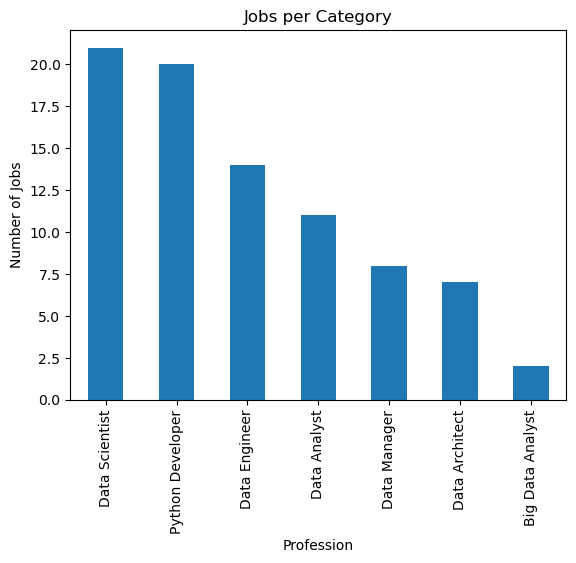

In [26]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36"
}


# keywords
professions = [
    "Data Scientist",
    "Data Analyst",
    "Python Developer",
    "Data Engineer",
    "Data Manager",
    "Data Architect",
    "Big Data Analyst",
    "Data Python"
]


df = pd.DataFrame(columns=[
    "profession",
    "title",
    "link",
    "company",
    "location"
])

session = requests.Session()


for profession in professions:

    query = profession.lower().replace(" ", "%20")

    url = f"https://www.jobs.ch/en/vacancies/?term={query}"

    response = session.get(url, headers=headers, timeout=10)

    soup = BeautifulSoup(response.text, "html.parser")


    job_ads = soup.find_all("a", {"data-cy": "job-link"})

    print(f"{profession} -> {len(job_ads)} jobs found")

    for job in job_ads:

        
        try:
            title = job.get("title")
        except:
            title = None

        
        try:
            link = "https://www.jobs.ch" + job.get("href")
        except:
            link = None

        # try to find parent for extra info
        parent = job.find_parent()

        # company
        try:
            company = parent.find("span").get_text(strip=True)
        except:
            company = None

        # location
        try:
            location = parent.find_all("p")[1].get_text(strip=True)
        except:
            location = None

        df = pd.concat([
            df,
            pd.DataFrame([{
                "profession": profession,
                "title": title,
                "link": link,
                "company": company,
                "location": location
            }])
        ], ignore_index=True)

# remove duplicates
df = df.drop_duplicates(subset=["title", "company"])

# save csv
df.to_csv("jobs.csv", index=False)

# show result
print(df.head())
print("\nTotal jobs:", len(df))

df["profession"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Jobs per Category"
)

plt.xlabel(
    "Profession"
)

plt.ylabel(
    "Number of Jobs"
)

plt.show()